<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/recovery/IQR_METHOD_OUTLIER_DETECTION_REMOVAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("placement.csv")
df.head(2)

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1


In [5]:
df.shape

(1000, 3)

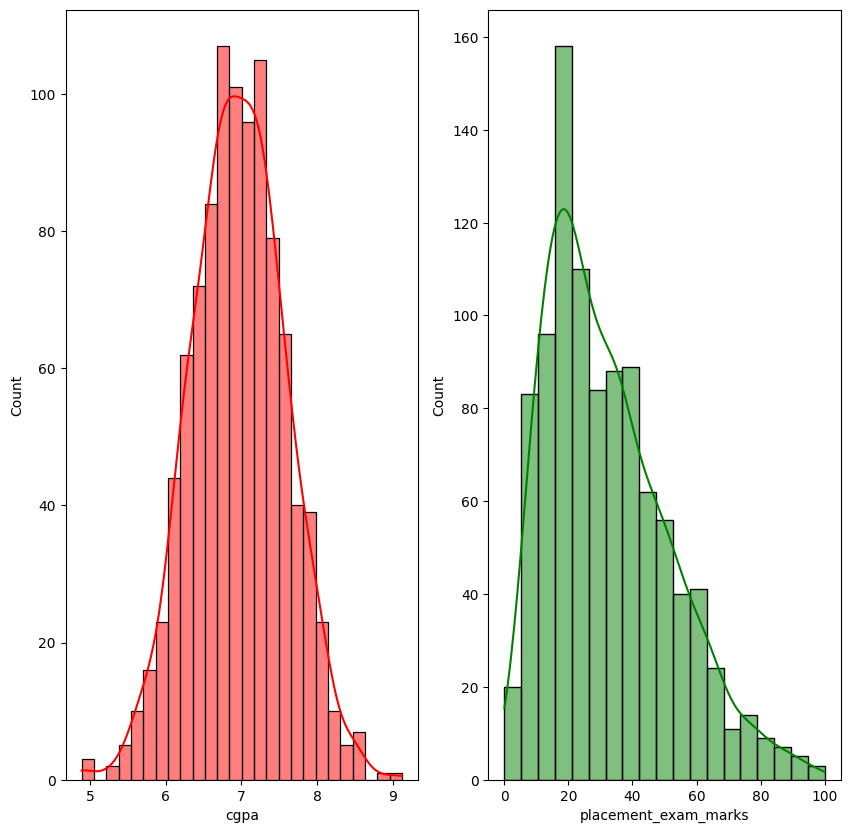

In [12]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True, color='red')
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True, color='green')
plt.show()

In [14]:
# Cgpa is normally distributed not skewed so its very very closed to 0
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [15]:
# it's right skewed because its very close to 1 np.float64(0.8356419499466834)
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

## Here You Can See total count is 1000 mean is -> 32.225000. 25% cadidates get below or equal to value of 17.000000. 50%	 cadidates get below or equal to value of 28.000000.75% cadidates get below or equal to value of	44.000000

In [16]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


In [17]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961240
std,0.615898
min,4.890000
25%,6.550000
50%,6.960000
75%,7.370000
max,9.120000


<Axes: ylabel='placement_exam_marks'>

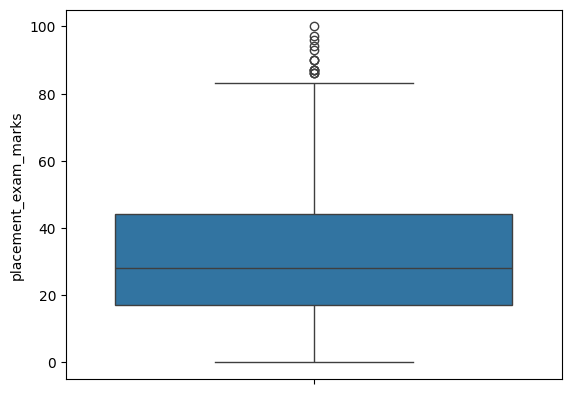

In [19]:
sns.boxplot(df['placement_exam_marks'])

In [20]:
## Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

percentile75

np.float64(44.0)

In [21]:
percentile25

np.float64(17.0)

In [23]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [25]:
upperlimit = percentile75 + 1.5 * iqr
lowerlimit = percentile25 - 1.5 * iqr

In [26]:
upperlimit

np.float64(84.5)

In [27]:
lowerlimit

np.float64(-23.5)

## Finding Outliers

In [28]:
df[df['placement_exam_marks'] > upperlimit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [31]:
df[df['placement_exam_marks'] < lowerlimit]

,cgpa,placement_exam_marks,placed


## Trimming

In [32]:
new_df = df[df['placement_exam_marks']< upperlimit]

In [33]:
new_df.shape

(985, 3)

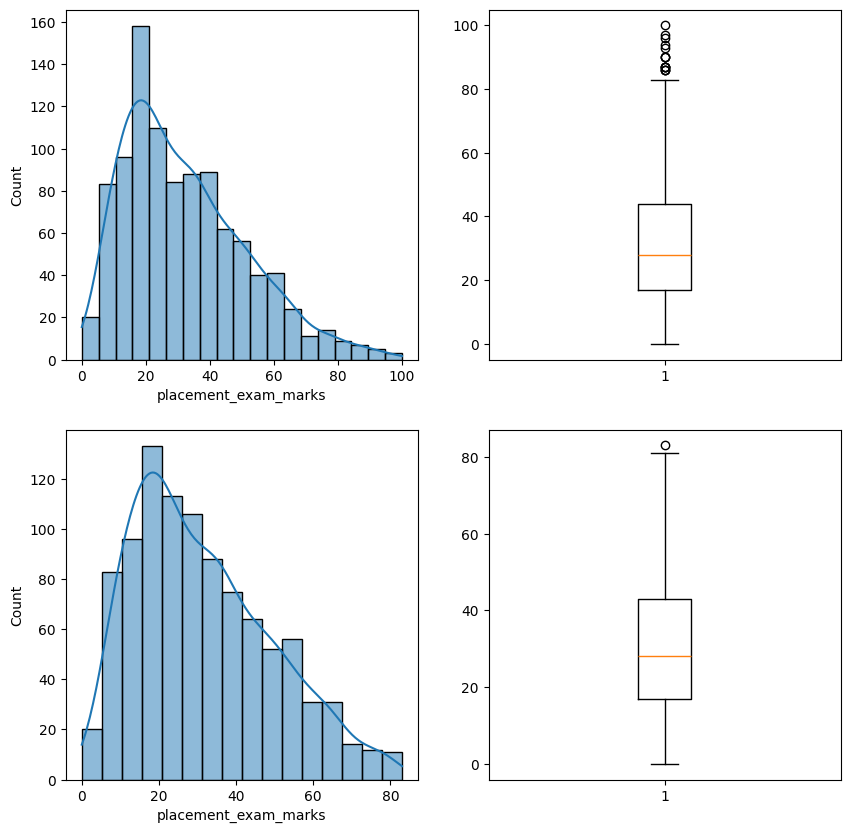

In [37]:
## Comparing

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.subplot(2,2,2)
plt.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'], kde=True)

plt.subplot(2,2,4)
plt.boxplot(new_df['placement_exam_marks'])

plt.show()


## Capping

In [40]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upperlimit,
    upperlimit,
    np.where(
        new_df_cap['placement_exam_marks'] < lowerlimit,
        lowerlimit,
        new_df_cap['placement_exam_marks']
    )
)

In [41]:
new_df_cap.shape

(1000, 3)

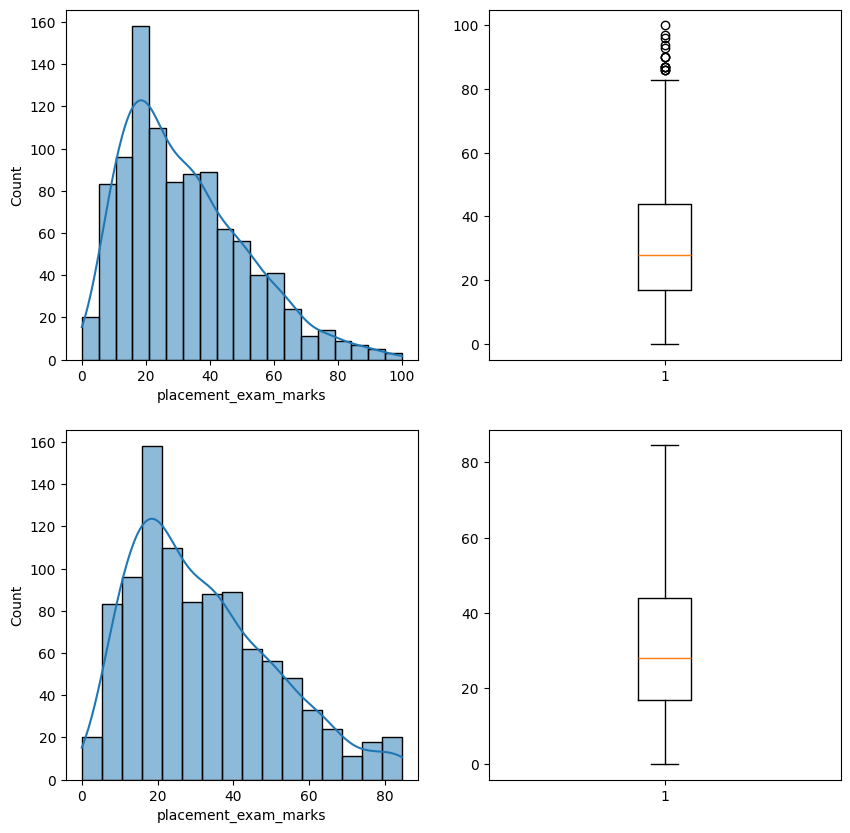

In [42]:
## Comparing

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.subplot(2,2,2)
plt.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'], kde=True)

plt.subplot(2,2,4)
plt.boxplot(new_df_cap['placement_exam_marks'])

plt.show()
